# Bubble analysis

Reviewed bubbles exported by `bubble_inference.ipynb` (`results/<RUN_NAME>/`), one or more frames per train.

**Physical picture:** each laser pulse ablates tissue and leaves cavitation/vapour bubbles. Between scan layers (trains,
minutes apart) the bubbles from earlier pulses **coalesce, drift, merge and dissolve**. That changes their number, size,
shape and position. The sections below track exactly these:

| section | question |
|---|---|
| 2 metrics table | all numbers per frame in one table (saved as `frame_metrics.csv`) |
| 3 count | how many bubbles, per frame and per mm² |
| 4 average size | mean, median and Sauter radius r₃₂ over time |
| 5 size distributions | histograms per frame, cumulative distributions, scaled distribution r/⟨r⟩ (self-similar coarsening?) |
| 6 size classes + coalescence check | which sizes disappear; is gas volume conserved (coalescence) or lost (dissolution)? |
| 7 overlays | every frame with bubbles coloured by area (green = small → red = large, one shared scale) |
| 8 spatial | where bubbles are, and how the population drifts |
| 9 shape | elongated bubbles (recent mergers) vs size and time |

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
import bubble_io as bio
import bubble_stats as bst

bst.style()

## CONFIG

In [2]:
RUN_DIR = "results/r563"
REVIEWED_ONLY = True          # only frames ticked "Reviewed" in napari
IN_ANALYSIS_ONLY = True       # apply the exclusions chosen at export (inner_margin, drop_edge_bubbles, ...)
TRAIN_TIMES = None            # optional {train: time}, e.g. {0: 0, 1: 2.5, 2: 5.0, ...}; None = train number
TIME_LABEL = "train"          # axis label, e.g. "time [min]"
UM_PER_PX = 3.2

HIST_VAR, HIST_LABEL = "r_eq_um", "equivalent radius [µm]"   # or "area_um2", "area [µm²]"
SIZE_CLASSES_UM = [0, 10, 20, 40, np.inf]                     # radius classes for section 6 (max 4 classes)
OVERLAY_CMAP = "RdYlGn_r"     # green (small) -> yellow -> red (large); "viridis" is colour-blind safe
OVERLAY_ALPHA = 0.45          # fill opacity of the overlays
DENSITY_CELL_UM = 80          # cell size of the spatial density maps

SAVE_FIGS = True              # save every figure as PNG into RUN_DIR/figures/
FIG_DIR = os.path.join(RUN_DIR, "figures")

def save(fig, name):
    if SAVE_FIGS:
        os.makedirs(FIG_DIR, exist_ok=True)
        fig.savefig(os.path.join(FIG_DIR, name + ".png"), dpi=200, bbox_inches="tight")

## 1. Load

In [3]:
bubbles, frames = bio.load_results(RUN_DIR, reviewed_only=REVIEWED_ONLY, in_analysis_only=IN_ANALYSIS_ONLY)
tmap = (lambda t: TRAIN_TIMES[t]) if TRAIN_TIMES else (lambda t: t)
bubbles["t"] = bubbles["train"].map(tmap)
frames["t"] = frames["train"].map(tmap)
frames = frames.sort_values(["t", "frame"]).reset_index(drop=True)
NATIVE_HW = (int(frames["image_height_px"].iloc[0]), int(frames["image_width_px"].iloc[0]))
print(f"{len(frames)} frames, trains {sorted(frames['train'].unique().tolist())}, {len(bubbles)} bubbles, "
      f"field of view {NATIVE_HW[1] * UM_PER_PX:.0f} × {NATIVE_HW[0] * UM_PER_PX:.0f} µm")
display(frames[["frame", "train", "frame_idx", "t", "n_bubbles", "n_in_analysis"]])

8 frames, trains [0, 1, 2, 3, 4, 5, 6, 7], 2548 bubbles, field of view 1280 × 800 µm


,frame,train,frame_idx,t,n_bubbles,n_in_analysis
0,r563_svd_normalised_tr050_tid0_015,0,15,0,306,306
1,r563_svd_normalised_tr050_tid1_015,1,15,1,287,287
2,r563_svd_normalised_tr050_tid2_015,2,15,2,267,267
3,r563_svd_normalised_tr050_tid3_015,3,15,3,232,232
4,r563_svd_normalised_tr050_tid4_015,4,15,4,392,392
5,r563_svd_normalised_tr050_tid5_015,5,15,5,386,386
6,r563_svd_normalised_tr050_tid6_015,6,15,6,359,359
7,r563_svd_normalised_tr050_tid7_015,7,15,7,319,319


**Columns in `bubbles`** (lengths in native px, `_um` / `_um2` in µm): `x, y` centre (edge bubbles: fitted centre,
may lie outside the image) · `area_px2`, `r_eq` full-bubble area and equivalent radius √(area/π) · `major_axis`,
`minor_axis`, `orientation_deg`, `eccentricity` · `area_visible_px2` part inside the image · `edge_truncated`,
`fit_kind`, `arc_deg`, `fit_reliable` edge handling · `in_analysis` export exclusions.

## 2. Metrics per frame

`r32_um` is the Sauter mean radius Σr³/Σr² (dominated by the large bubbles, standard in foam/bubble science),
`polydispersity` = std/mean of r, `coverage_frac` = fraction of the frame covered by at least one bubble (overlaps
counted once), `volume_um3` = Σ 4/3πr³ (sphere-equivalent gas volume proxy), `cx_um, cy_um` = area-weighted centroid.

In [5]:
m = bst.frame_metrics(bubbles, frames, run_dir=RUN_DIR, um_per_px=UM_PER_PX)
m.to_csv(os.path.join(RUN_DIR, "frame_metrics.csv"), index=False)
cols = ["train", "t", "n_bubbles", "density_per_mm2", "r_mean_um", "r_sem_um", "r_median_um", "r32_um", "r_max_um",
        "polydispersity", "coverage_frac", "area_total_um2", "volume_um3", "frac_noncircular", "n_edge"]
display(m[cols].round(3))

,train,t,n_bubbles,density_per_mm2,r_mean_um,r_sem_um,r_median_um,r32_um,r_max_um,polydispersity,coverage_frac,area_total_um2,volume_um3,frac_noncircular,n_edge
0,0,0,306,298.828,19.583,0.733,16.481,38.779,85.146,0.654,0.333,526014.240,2.719773e+07,0.069,18
1,1,1,287,280.273,20.031,0.761,16.990,38.915,85.206,0.644,0.326,511265.944,2.652798e+07,0.070,20
2,2,2,267,260.742,20.370,0.799,17.096,39.272,85.157,0.641,0.320,490476.178,2.568247e+07,0.060,19
3,3,3,232,226.562,21.280,0.848,18.044,39.338,84.561,0.607,0.307,451023.016,2.365664e+07,0.060,19
4,4,4,392,382.812,16.155,0.579,12.414,36.684,84.227,0.710,0.337,483066.134,2.362763e+07,0.069,14
5,5,5,386,376.953,17.077,0.620,13.697,37.869,85.388,0.713,0.335,532877.417,2.690591e+07,0.057,19
6,6,6,359,350.586,17.338,0.634,14.126,37.631,89.081,0.693,0.324,501407.306,2.515810e+07,0.058,21
7,7,7,319,311.523,17.204,0.706,13.443,39.465,89.759,0.732,0.311,455265.054,2.395599e+07,0.078,17


## 3. Bubble count

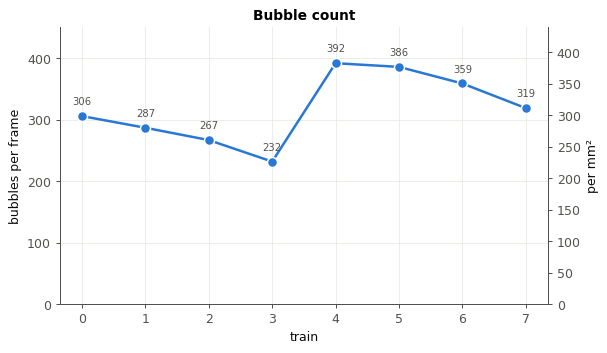

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
bst.plot_count(m, TIME_LABEL, ax=ax)
save(fig, "count")

## 4. Average bubble size

Mean and median describe the *typical* bubble. The Sauter radius r₃₂ follows the *large* bubbles, which hold most of
the gas. Growth of all three with fewer bubbles is the signature of coalescence. A sudden drop marks a fresh
population of small bubbles (e.g. a new scan layer).

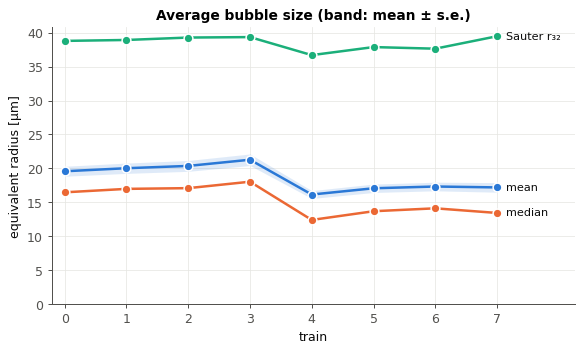

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4))
bst.plot_mean_size(m, TIME_LABEL, ax=ax)
save(fig, "mean_size")

## 5. Size distributions

* **Histograms** (log bins): one panel per frame, the first frame as dashed outline for comparison.
* **Cumulative distributions**: a curve shifting right = bubbles growing.
* **Scaled distribution** r/⟨r⟩: if the curves collapse onto one shape, the foam coarsens self-similarly (only the
  scale changes). A curve that does not collapse points to a different process, such as a new bubble population.

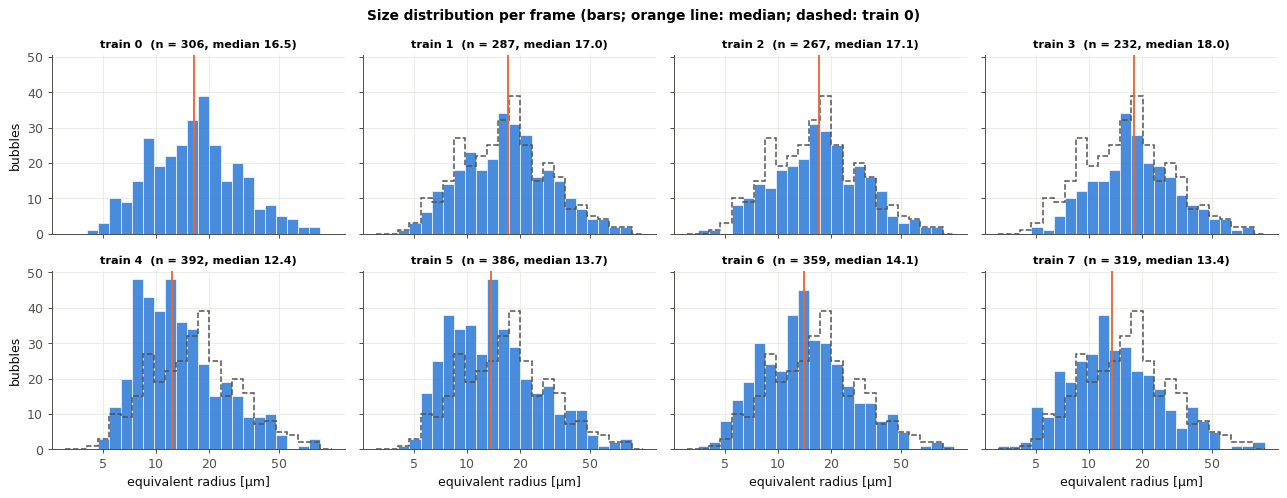

In [8]:
fig = bst.plot_histograms(bubbles, m, var=HIST_VAR, xlabel=HIST_LABEL)
save(fig, "histograms")

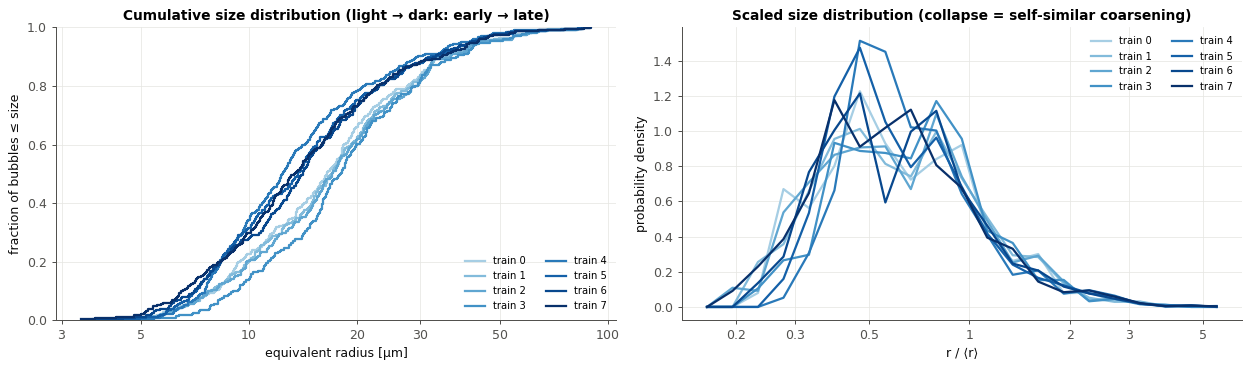

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
bst.plot_cdfs(bubbles, m, var=HIST_VAR, xlabel=HIST_LABEL, ax=ax[0])
bst.plot_scaled_distribution(bubbles, m, ax=ax[1])
fig.tight_layout()
save(fig, "distributions")

## 6. Size classes and coalescence check

* **Size classes:** whether small bubbles vanish while large ones gain.
* **Relative change** (all quantities divided by their value in the first frame):
  * pure **coalescence** keeps the gas volume roughly constant while the count falls and the radius grows;
  * **dissolution** loses volume;
  * **new bubbles** raise the count and lower the radius.

  The volume proxy assumes spherical bubbles seen in projection, so read trends, not absolute values.

size_class,t,frame,0–10 µm,10–20 µm,20–40 µm,≥ 40 µm
0,0,r563_svd_normalised_tr050_tid0_015,69,133,81,23
1,1,r563_svd_normalised_tr050_tid1_015,59,120,85,23
2,2,r563_svd_normalised_tr050_tid2_015,54,110,81,22
3,3,r563_svd_normalised_tr050_tid3_015,32,108,71,21
4,4,r563_svd_normalised_tr050_tid4_015,134,173,65,20
5,5,r563_svd_normalised_tr050_tid5_015,122,168,72,24
6,6,r563_svd_normalised_tr050_tid6_015,101,161,76,21
7,7,r563_svd_normalised_tr050_tid7_015,95,139,64,21


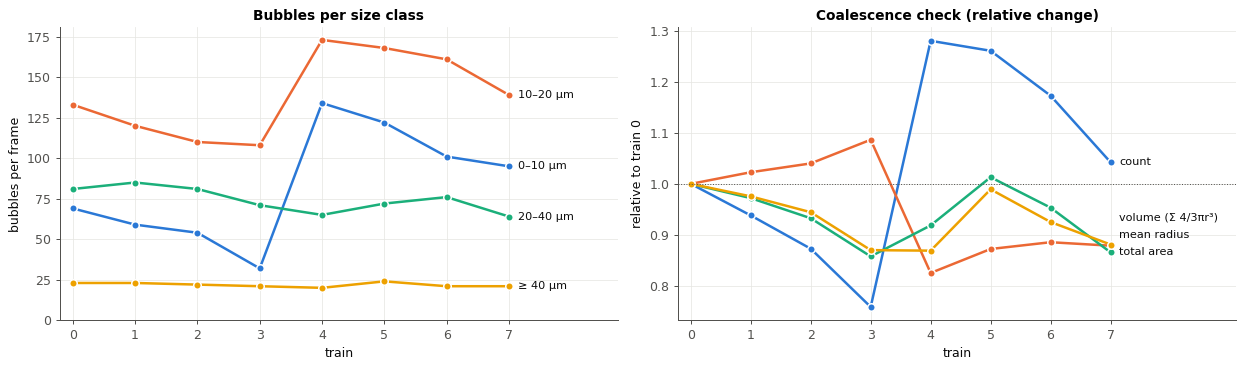

In [10]:
counts, labels = bst.size_class_counts(bubbles, SIZE_CLASSES_UM)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
bst.plot_size_classes(counts, labels, TIME_LABEL, ax=ax[0])
bst.plot_relative(m, TIME_LABEL, ax=ax[1])
fig.tight_layout()
save(fig, "size_classes_relative")
display(counts)

## 7. Overlays coloured by bubble area

Green = small, red = large, on one **shared logarithmic** colour scale, so the same colour means the same area in
every frame. Large bubbles are drawn first so small ones on top stay visible.

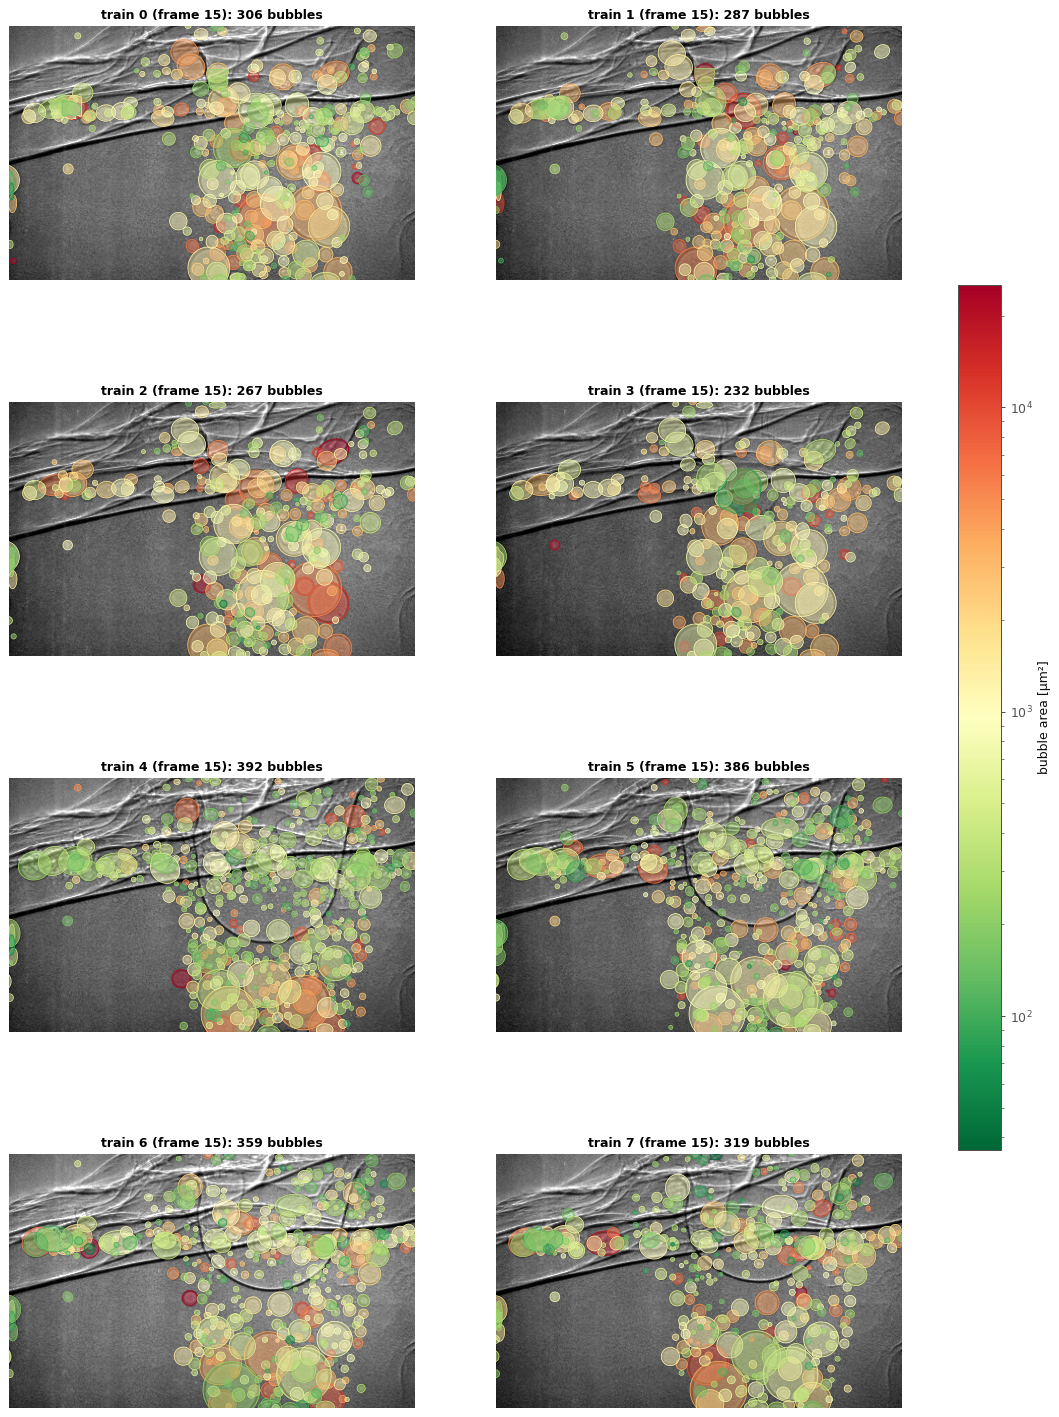

In [11]:
norm = bst.area_norm(bubbles, "area_um2")
ncols = 2
nrows = int(np.ceil(len(m) / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(8 * ncols, 5.2 * nrows), squeeze=False)
for ax, (_, r) in zip(axs.ravel(), m.iterrows()):
    img, shapes = bio.load_frame(RUN_DIR, r["frame"])
    b = bubbles[bubbles["frame"] == r["frame"]]
    bst.plot_area_overlay(img, [shapes[i] for i in b["bubble_id"]], b["area_um2"].to_numpy(), norm,
                          cmap=OVERLAY_CMAP, ax=ax, alpha=OVERLAY_ALPHA,
                          title=f"train {r['train']} (frame {r['frame_idx']}): {len(b)} bubbles")
for ax in axs.ravel()[len(m):]:
    ax.set_visible(False)
sm = plt.cm.ScalarMappable(norm=norm, cmap=OVERLAY_CMAP)
fig.colorbar(sm, ax=axs.ravel().tolist(), shrink=0.6, label="bubble area [µm²]")
save(fig, "overlays_area")

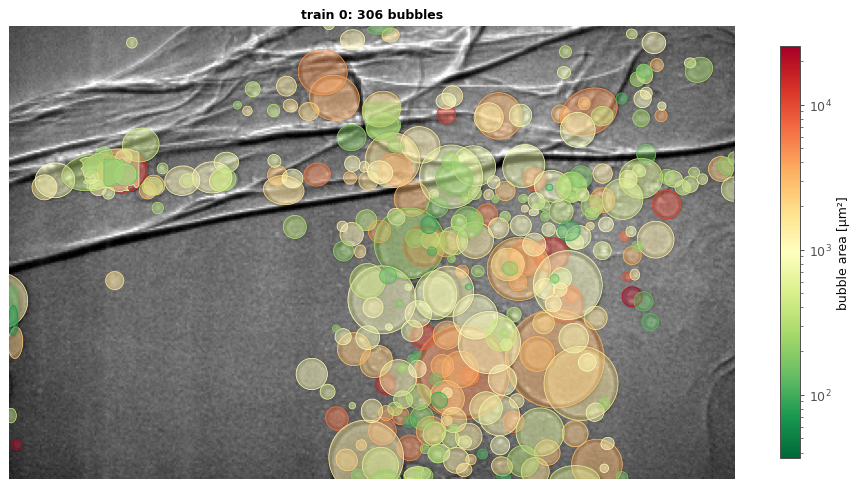

In [12]:
# one frame, large
SHOW_TRAIN = int(m["train"].iloc[0])
r = m[m["train"] == SHOW_TRAIN].iloc[0]
img, shapes = bio.load_frame(RUN_DIR, r["frame"])
b = bubbles[bubbles["frame"] == r["frame"]]
fig, ax = plt.subplots(figsize=(13, 8.5))
bst.plot_area_overlay(img, [shapes[i] for i in b["bubble_id"]], b["area_um2"].to_numpy(), norm,
                      cmap=OVERLAY_CMAP, ax=ax, alpha=OVERLAY_ALPHA, title=f"train {SHOW_TRAIN}: {len(b)} bubbles")
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=OVERLAY_CMAP), ax=ax, shrink=0.7, label="bubble area [µm²]")
save(fig, f"overlay_area_train{SHOW_TRAIN}")

## 8. Spatial distribution and drift

Density maps show where the bubbles sit (shared colour scale). The centroid path follows the area-weighted centre of
the whole population from train to train: a consistent direction means collective drift (e.g. buoyancy or flow).
Individual bubbles are not tracked, because they merge and move too much between trains.

,train,t,cx_um,cy_um,step_um
0,0,0,765.8,447.9,NaN
1,1,1,769.4,450.4,4.4
2,2,2,774.1,450.6,4.7
3,3,3,776.0,454.0,3.9
4,4,4,737.8,442.0,40.1
5,5,5,735.0,445.7,4.6
6,6,6,754.4,441.7,19.7
7,7,7,746.7,449.0,10.7


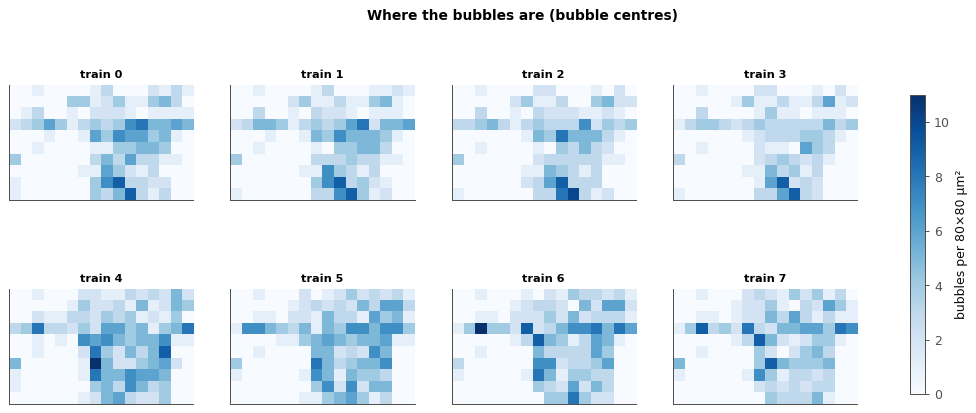

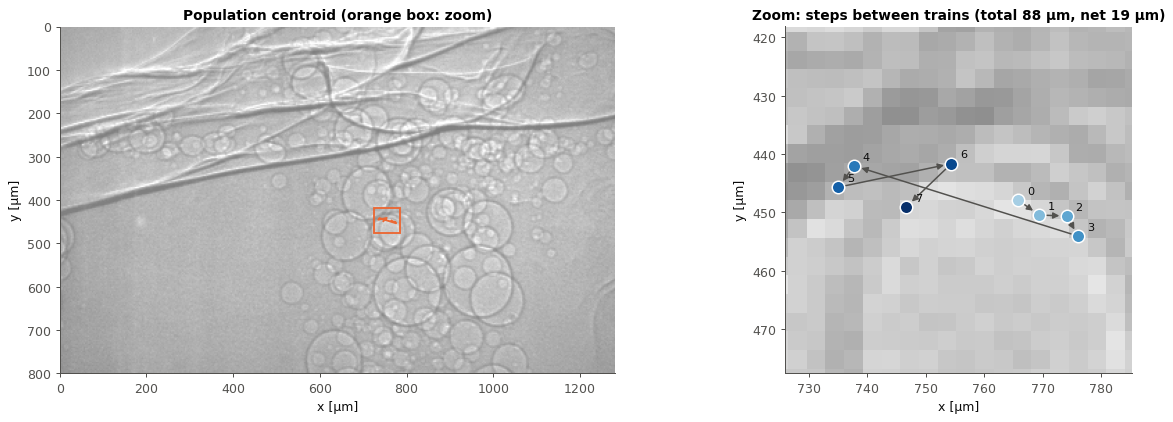

In [13]:
fig = bst.plot_density_maps(bubbles, m, NATIVE_HW, um_per_px=UM_PER_PX, cell_um=DENSITY_CELL_UM)
save(fig, "density_maps")

img0, _ = bio.load_frame(RUN_DIR, m["frame"].iloc[0])
fig = bst.plot_drift(m, NATIVE_HW, um_per_px=UM_PER_PX, img=img0)
save(fig, "drift")
display(m[["train", "t", "cx_um", "cy_um"]].assign(
    step_um=np.r_[np.nan, np.hypot(np.diff(m["cx_um"]), np.diff(m["cy_um"]))]).round(1))

## 9. Shape

Freshly merged bubbles are elongated before surface tension rounds them. The share of non-circular bubbles is a rough
indicator of recent merging activity.

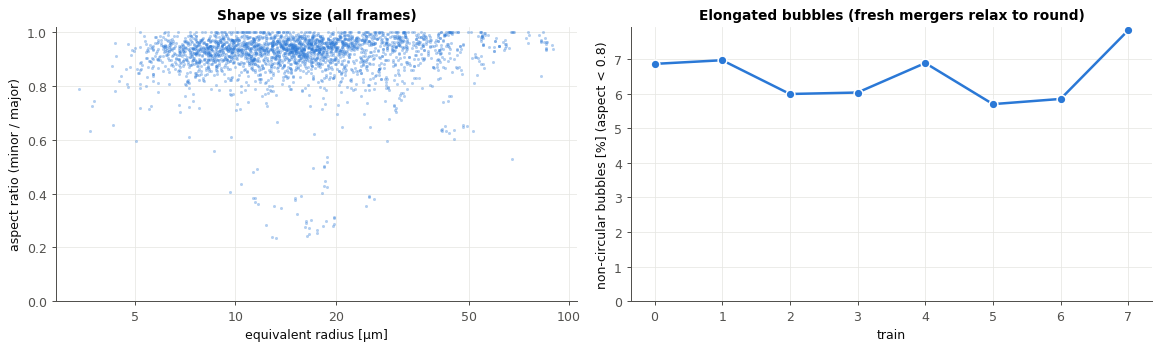

In [14]:
fig = bst.plot_shape(bubbles, m, TIME_LABEL)
save(fig, "shape")

## Caveats

* Images are 2-D projections of a 3-D foam: overlapping bubbles are all counted, `area_total_um2` can exceed the frame
  area, and `coverage_frac` counts overlaps once.
* Bubbles cut by the image edge use their fitted full size (`fit_reliable=False` for short visible arcs). Use the
  export options (`inner_margin`, `drop_unreliable_fits`) if edge effects matter for a comparison.
* With one frame per train, frame-to-frame scatter within a train is unknown. Analysing 3–5 frames per train
  gives error bars, and `frame_metrics` handles several frames per train automatically.

## Your analysis